# Fit of the VCA with magnetic end springs

Fits a nonlinear model to the chirp data in `data/train` and `data/test`:

$$m\ddot{x} = \Gamma\, i - c\,\dot{x} - F_s(x)$$

| Symbol | Meaning | Initial guess |
|---|---|---|
| $m$ | moving mass | 51.5 kg (fixed) |
| $\Gamma$ | motor constant | 283 N/A (datasheet) |
| $c$ | viscous damping | NA |
| $C_\mu$ | magnet coupling constant | 2.423 N·m² (PDF eq. 13) |
| $g_0$ | magnet gap at centre | 22.3 mm (experiment, measured) |

**Strategy.** All fits are sequential, on two experiment types (Stage 0):
1. Stage 1: on the plain chirp at high frequency and low amplitude, the spring force is negligible; fit $\Gamma$ and $c$.
2. Method A: on the scheduled chirp from 10 Hz up to `F_MAX_A`, fit the spring with $\Gamma$, $c$ fixed from Stage 1: Method A a cubic polynomial, Method B an odd polynomial with a position-dependent $\Gamma(x)$, Method C two unequal repelling magnets.

**Discrete-time model.** RK4 with $T_s$ = 1 ms (log at 2 kHz, every other sample kept) and zero-order-hold input. Predictions start from the measured $(x, \dot{x})$; models are compared on position NRMSE against prediction horizon.

**Assumptions**
- Constant $\Gamma$ (PDF Assumption 1), no equilibrium offset.
- Input is `actual_current_A`; position is `position_mm` (converted in C), shifted back by `TAU` to align it with the current and notched at 50/150 Hz (mains pickup); the fits use the position-derived acceleration. The accelerometer (`ai2_corrected_V`, shifted by `TAU_ACC`) is only plotted for comparison.
- Current, position and acceleration are zero-phase low-pass filtered (4th-order Butterworth, 100 Hz) before decimation; the t < 0 idle window is dropped. $\dot{x}$ is the gradient of the filtered position.

In [90]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import signal
from scipy.optimize import least_squares

sns.set_theme(style="whitegrid")

FS_LOG, DECIM = 2000.0, 2
TS = 1/1000.0                       # discretization inter-sampling time
M = 51.5                            # kg
GAMMA0, C0 = 283.0, 1700.0          # datasheet; iteration
CMU0, G00 = 2.423, 22.3e-3          # PDF eq. 13; measured gap in experiment
s_ds = lambda x: (283 - 0.0198 * (x * 1e3) - 0.578 * (x * 1e3)**2) / 283   # datasheet K_f(z) shape, z in mm, 1 at the centre
LF_MAX, HF_MIN = 5.0, 37.0          # Hz; Low freq range and high freq range, ub and lb (37 Hz: above the 35.5 Hz laser-mount mode)
H_FIT, H_EVAL, STRIDE = 500, 500, 10 # steps for fitting the data
FOH = False                         # Zero-order hold
TAU = 0.65e-3                       # s, position is logged this much later than current; undone in load
TAU_ACC = 2.65e-3                   # s, accelerometer is logged this much later than current; undone in load
T_CUT = 5.0                         # s, end of each run left out of the HF band
ACC_SCALE_V_PER_G = 0.0578 * 0.65   # accelerometer V/g: plot-script 0.0578 corrected by the gain against position above 35 Hz (0.60-0.68)
F_MAX_A = 55.0                      # Hz, Methods A-C use the scheduled chirp up to this frequency (55 = whole run; 34 stays below the 35.5 Hz mode)

b_lp, a_lp = signal.butter(4, 100.0 / (FS_LOG / 2))   # 4th-order 100 Hz low-pass


def load(path):
    "Read one log; return filtered current, position and acceleration at 1 kHz (t >= 0), velocity, and band masks."
    # chirp start/end frequency and duration from the file name, e.g. ..._1.0to55.0Hz_120.0s_...
    f0, f1, T = map(float, re.search(r"_([\d.]+)to([\d.]+)Hz_([\d.]+)s_", path.name).groups())
    raw = np.loadtxt(path, delimiter=",", skiprows=2)   # skip header and the duplicate first row
    lp = lambda s: signal.filtfilt(b_lp, a_lp, s)       # zero-phase, also the anti-alias filter for decimation
    # columns 0 time_s, 1 actual_current_A, 11 position_mm, 12 ai2_corrected_V (bias removed in firmware)
    t = raw[:, 0]
    x = np.interp(t + TAU, t, lp(raw[:, 11] * 1e-3))   # shift position back by TAU to align it with the current
    for f_n in (50.0, 150.0):                           # mains pickup in the laser signal
        x = signal.filtfilt(*signal.iirnotch(f_n, 30.0, fs=FS_LOG), x)
    a = np.interp(t + TAU_ACC, t, lp(raw[:, 12])) / ACC_SCALE_V_PER_G * 9.81   # measured acceleration, shifted back by TAU_ACC
    keep = slice(np.searchsorted(t, 0.0), None, DECIM)  # drop the t < 0 idle window, 2 kHz -> 1 kHz
    d = dict(t=t[keep], i=lp(raw[:, 1])[keep], x=x[keep], a_meas=a[keep])
    d["v"] = np.gradient(d["x"], TS)                    # velocity: initial states and LLS
    d["a_x"] = np.gradient(d["v"], TS)                  # acceleration from position
    d["a"] = d["a_x"]                                   # fits use position-derived acceleration; accelerometer only plotted
    f = f0 * (f1 / f0) ** (d["t"] / T)                  # instantaneous frequency of the exponential chirp
    d["lf"] = f <= LF_MAX                               # old low band, used by methods B-D
    d["hf"] = (f >= HF_MIN) & (d["t"] <= d["t"][-1] - T_CUT)
    d["sweep"] = f <= F_MAX_A                           # Methods A-C window: scheduled chirp from its start up to F_MAX_A
    return d


def step(x, v, u0, u1, acc):
    "One RK4 step of (x, v) with input u0 at the start and u1 at the end of the step."
    um = 0.5 * (u0 + u1)
    k1x, k1v = v, acc(x, v, u0)
    k2x, k2v = v + TS / 2 * k1v, acc(x + TS / 2 * k1x, v + TS / 2 * k1v, um)
    k3x, k3v = v + TS / 2 * k2v, acc(x + TS / 2 * k2x, v + TS / 2 * k2v, um)
    k4x, k4v = v + TS * k3v, acc(x + TS * k3x, v + TS * k3v, u1)
    return x + TS / 6 * (k1x + 2 * k2x + 2 * k3x + k4x), v + TS / 6 * (k1v + 2 * k2v + 2 * k3v + k4v)


def rollout(Fs, p, d, s, H):
    "Predicted x, shape (len(s), H+1), from the measured state at each start index s. p = [Gamma, c, *spring]."
    acc = lambda x, v, u: (p[0] * u - p[1] * v - Fs(x, u, p[2:])) / M      # Fs gets the current too, for Gamma(x)
    x, v, out = d["x"][s], d["v"][s], [d["x"][s]]
    with np.errstate(all="ignore"):
        for k in range(H):
            u0 = d["i"][s + k]
            x, v = step(x, v, u0, d["i"][s + k + 1] if FOH else u0, acc)
            out.append(x)
    return np.stack(out, axis=1)


def starts(d, band, H):
    "Every STRIDE-th sample of the band whose H-step horizon fits in the record."
    s = np.flatnonzero(band)[::STRIDE]
    return s[s + H < len(d["x"])]


def target(d, s, H):
    "Measured x over the horizon of each start, shape (len(s), H+1)."
    return d["x"][s[:, None] + np.arange(H + 1)]


def fit(Fs, p0, d, band, lb=-np.inf, free=slice(None), detrend=False):
    "H-step-ahead fit of p0[free]; detrend removes per-start mean and slope of the error (free-mass drift)."
    s = starts(d, band, H_FIT)
    X = target(d, s, H_FIT)[:, 1:]
    p = np.array(p0, float)
    def res(q):
        p[free] = q
        e = np.nan_to_num(rollout(Fs, p, d, s, H_FIT)[:, 1:], nan=1.0, posinf=1.0, neginf=-1.0) - X   # diverged rollout -> 1 m
        return (signal.detrend(e, axis=1) if detrend else e).ravel()
    r = least_squares(res, p[free], x_scale=np.abs(p[free]), bounds=(lb, np.inf))
    p[free] = r.x
    print(f"{r.message} ({r.nfev} evaluations)")
    return p


def nrmse_curve(Fs, p, d, band, H=H_EVAL):
    "Position RMS error per horizon step, normalised by the std of x in the band."
    s = starts(d, band, H)
    e = rollout(Fs, p, d, s, H) - target(d, s, H)
    return np.sqrt(np.mean(e ** 2, axis=0)) / np.std(d["x"][band])


CURVES = []

def evaluate(name, Fs, p, exp, band, H=H_EVAL):
    "Left: NRMSE against horizon, train and test. Right: one H-step prediction on test, started mid-band."
    fig, ax = plt.subplots(1, 2, figsize=(15, 4))
    k = np.arange(1, H + 1)
    for split, d in DATA[exp].items():
        e = nrmse_curve(Fs, p, d, d[band], H)[1:]
        CURVES.append(dict(method=name, split=split, exp=exp, band=band, k=k, nrmse=e))   # kept for the comparison cell
        sns.lineplot(x=k, y=e, ax=ax[0], label=split)
        print(f"{split:5s} NRMSE at k = 1, 10, 100, {H}: " + ", ".join(f"{e[j - 1]:.3f}" for j in (1, 10, 100, H)))
    ax[0].set(xscale="log", xlabel="steps ahead (1 step = 1 ms)", ylabel="position NRMSE", title=f"{name}, {band.upper()} band")
    d = DATA[exp]["test"]
    s0 = starts(d, d[band], H)
    s0 = s0[len(s0) // 2:][:1]                          # one start in the middle of the band
    t = d["t"][s0[0]:s0[0] + H + 1]
    sns.lineplot(x=t, y=target(d, s0, H)[0] * 1e3, ax=ax[1], label="measured", color="k")
    sns.lineplot(x=t, y=rollout(Fs, p, d, s0, H)[0] * 1e3, ax=ax[1], label="predicted")
    ax[1].set(xlabel="time (s)", ylabel="x (mm)", title=f"test: {H}-step prediction from the measured state")
    plt.tight_layout(); plt.show()


# self-check: undamped linear spring from x = 1 mm must follow cos(wt)
_k = 1e5
_d = dict(x=np.full(2, 1e-3), v=np.zeros(2), i=np.zeros(1000))
_x = rollout(lambda x, u, q: q[0] * x, [0.0, 0.0, _k], _d, np.array([0]), 900)[0]
assert np.allclose(_x, 1e-3 * np.cos(np.sqrt(_k / M) * TS * np.arange(901)), atol=1e-8)

## Stage 0: data

Two experiment types per split, from `data/train` and `data/test`:
- `chirp`: plain chirp, 1→55 Hz, for Stage 1 (band `hf`: ≥ `HF_MIN` Hz, last `T_CUT` s cut).
- `chirpsched`: chirp 10→55 Hz with amplitude ramps, for Method A (band `sweep`: from the start up to `F_MAX_A` Hz).

The 3 s idle window (t < 0) is dropped; position is notched at 50 and 150 Hz (mains pickup in the laser). The fits use the position-derived acceleration; the bias-corrected accelerometer `ai2_corrected_V` is only plotted for comparison.

chirp      train a_meas / a_from_x = 1.142
chirp      test  a_meas / a_from_x = 1.106
chirpsched train a_meas / a_from_x = 1.225
chirpsched test  a_meas / a_from_x = 1.242


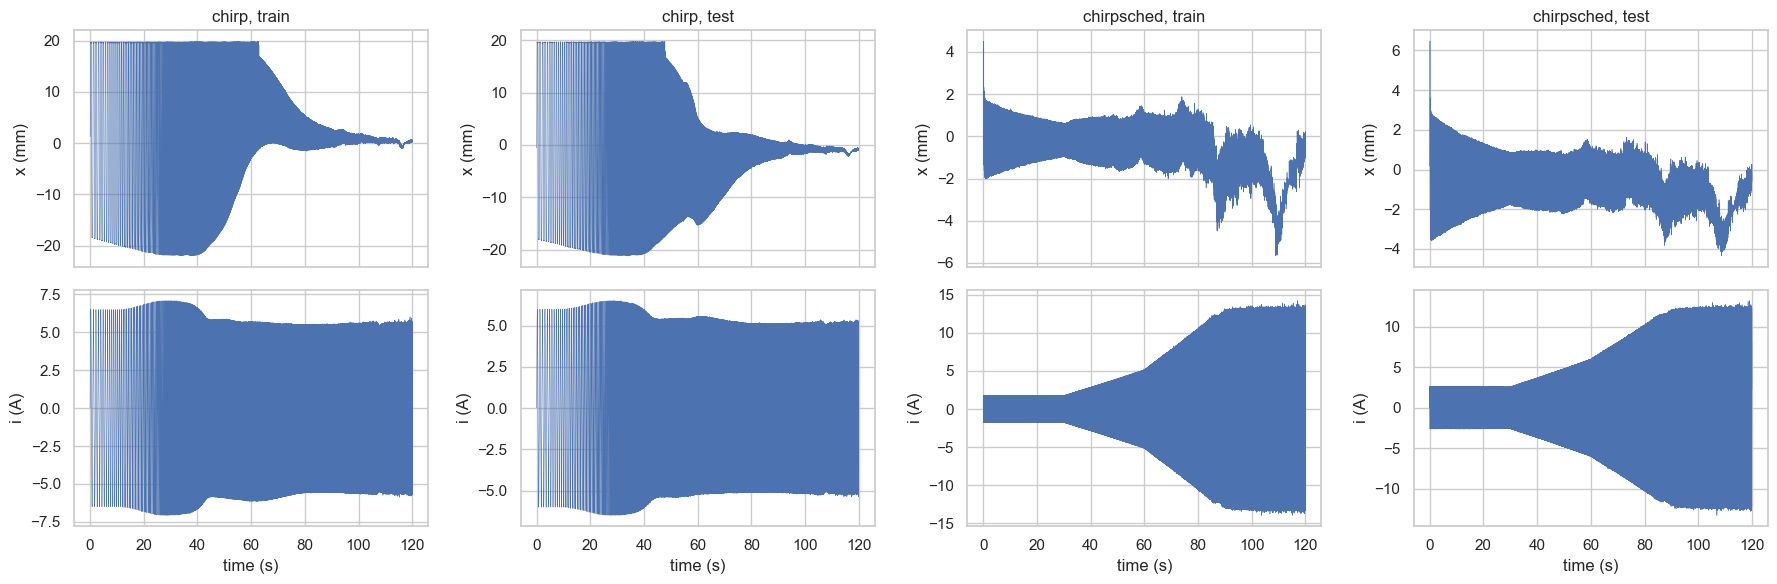

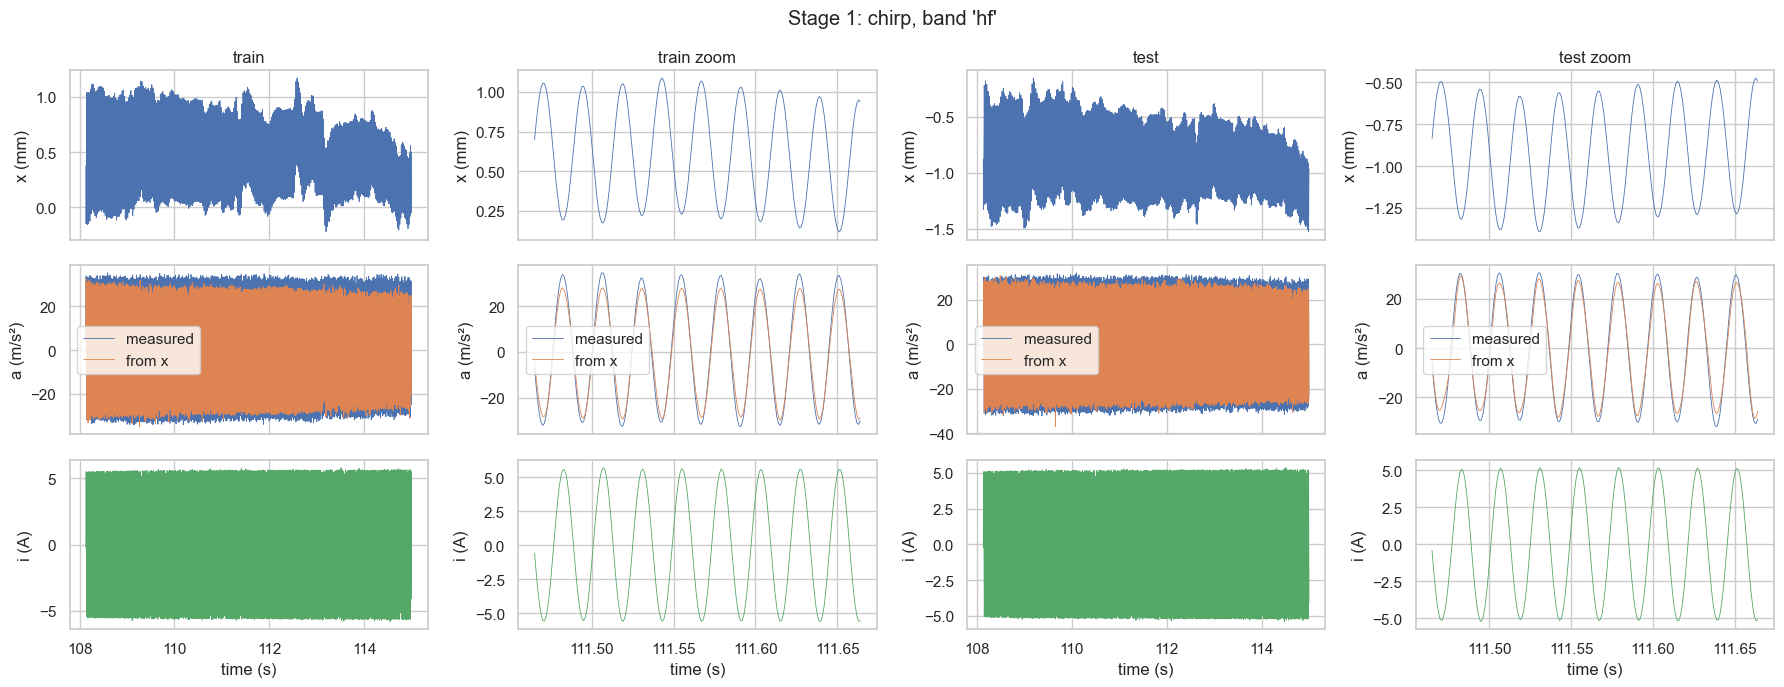

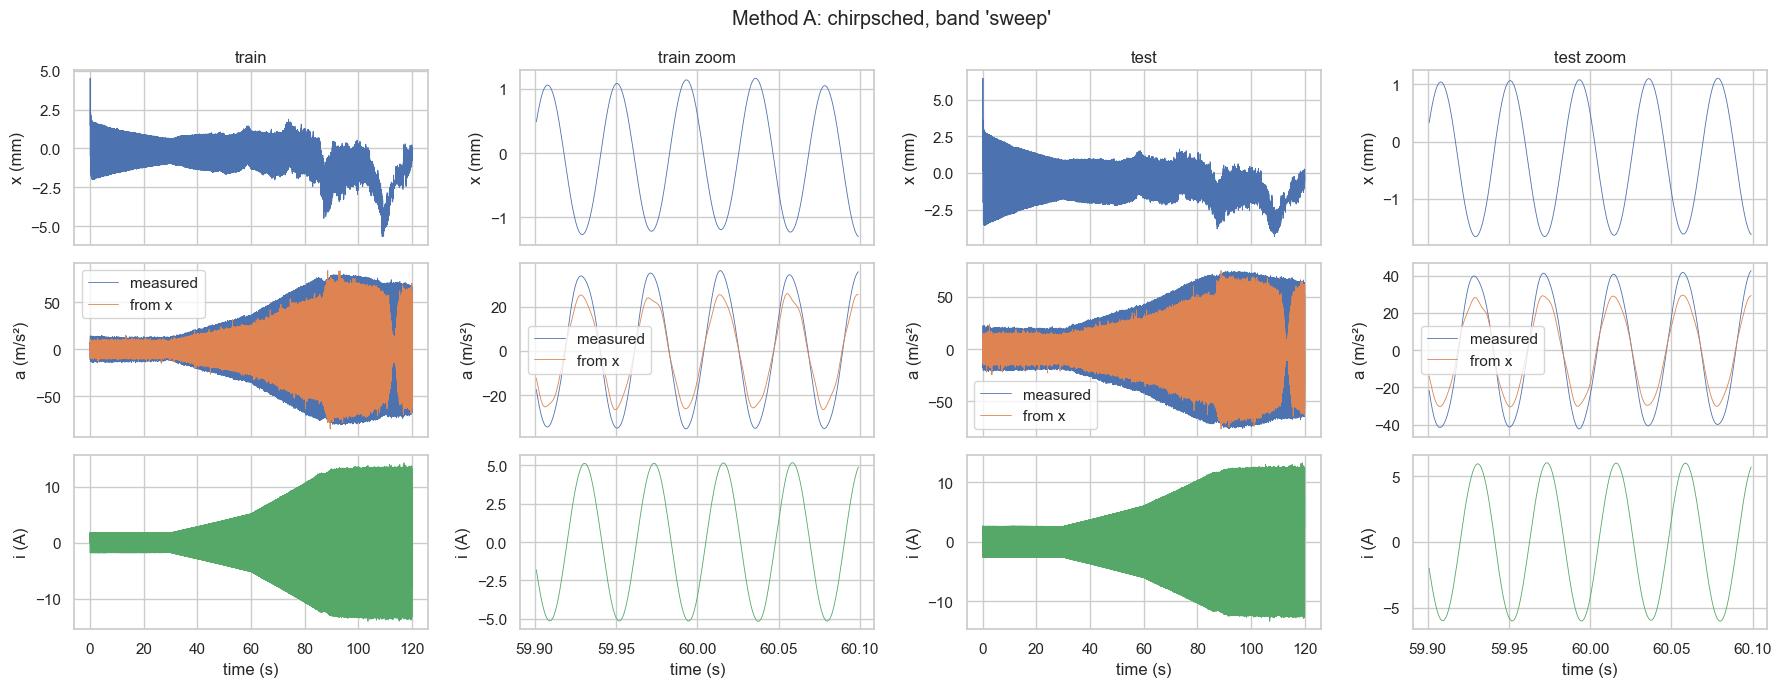

In [91]:
DATA = {exp: {s: load(next(Path("data", s).glob(f"voice_coil_log_{exp}_*.csv"))) for s in ("train", "test")}
        for exp in ("chirp", "chirpsched")}
USE = [("Stage 1", "chirp", "hf"), ("Method A", "chirpsched", "sweep")]

# accelerometer scale check: slope of measured against position-derived acceleration, 1.0 if ACC_SCALE_V_PER_G is right
for exp, runs in DATA.items():
    for split, d in runs.items():
        m = d["hf"] | d["sweep"] if exp == "chirpsched" else d["hf"]
        print(f"{exp:10s} {split:5s} a_meas / a_from_x = {np.polyfit(d['a_x'][m], d['a_meas'][m], 1)[0]:.3f}")

# overview: position (top) and current (bottom) of every run
fig, ax = plt.subplots(2, 4, figsize=(18, 6), sharex="col")
for col, (exp, split) in enumerate([(e, s) for e in DATA for s in DATA[e]]):
    d = DATA[exp][split]
    sns.lineplot(x=d["t"], y=d["x"] * 1e3, ax=ax[0, col], lw=0.4).set(title=f"{exp}, {split}", ylabel="x (mm)")
    sns.lineplot(x=d["t"], y=d["i"], ax=ax[1, col], lw=0.4).set(xlabel="time (s)", ylabel="i (A)")
plt.tight_layout(); plt.show()

# data actually used, one figure per fit: rows position, acceleration, current;
# columns train (whole window, zoom), test (whole window, zoom). The zoom shows a few cycles mid-window to judge delays.
ZOOM_S = 0.2                                            # s, length of the zoom window
for stage, exp, band in USE:
    fig, ax = plt.subplots(3, 4, figsize=(18, 7), sharex="col")
    for k, (split, d) in enumerate(DATA[exp].items()):
        idx = np.flatnonzero(d[band])
        t_mid = d["t"][idx[len(idx) // 2]]
        for col, m in [(2 * k, d[band]), (2 * k + 1, d[band] & (np.abs(d["t"] - t_mid) <= ZOOM_S / 2))]:
            t = d["t"][m]
            sns.lineplot(x=t, y=d["x"][m] * 1e3, ax=ax[0, col], lw=0.6).set(title=f"{split}{' zoom' if col % 2 else ''}", ylabel="x (mm)")
            sns.lineplot(x=t, y=d["a_meas"][m], ax=ax[1, col], lw=0.6, label="measured")
            sns.lineplot(x=t, y=d["a_x"][m], ax=ax[1, col], lw=0.6, label="from x").set(ylabel="a (m/s²)")
            sns.lineplot(x=t, y=d["i"][m], ax=ax[2, col], lw=0.6, color="C2").set(xlabel="time (s)", ylabel="i (A)")
    fig.suptitle(f"{stage}: {exp}, band '{band}'"); plt.tight_layout(); plt.show()

## Stage 1: motor constant (HF, plain chirp)

Plain chirp, band `hf`: ≥ `HF_MIN` Hz with the last `T_CUT` s cut. We fit $\Gamma$ and $c$ by bounded linear least squares (`lsq_linear`, $c \geq 0$), optionally with a linear spring $k\,x$ (`SPRING`):

$$m\ddot{x} = \Gamma\, i - c\,\dot{x}\;[-\,k\,x]$$

In [92]:
from scipy.optimize import lsq_linear

SPRING = False                                          # add a linear spring k x to Stage 1
d, sel = DATA["chirp"]["train"], DATA["chirp"]["train"]["hf"]
cols = {"Gamma": d["i"], "c": -d["v"]}                  # m a = Gamma i - c v [- k x]
if SPRING:
    cols["k"] = -d["x"]
A = np.column_stack(list(cols.values()))[sel]
lb = [0.0 if n == "c" else -np.inf for n in cols]       # c >= 0
p_hf = lsq_linear(A, M * d["a"][sel], bounds=(lb, np.inf)).x
print(", ".join(f"{n} = {val:.4g}" for n, val in zip(cols, p_hf)))
stage1_force = lambda x, u, q: q[0] * x if SPRING else 0.0 * x

Gamma = 260.8, c = 1126


Prediction with the fitted Stage 1 terms (without a spring the model is a free mass and drifts):

$$m\ddot{x} = \Gamma\, i - c\,\dot{x}\;[-\,k\,x]$$

train NRMSE at k = 1, 10, 100, 600: 0.003, 0.326, 1.743, 4.798
test  NRMSE at k = 1, 10, 100, 600: 0.003, 0.367, 1.729, 3.379


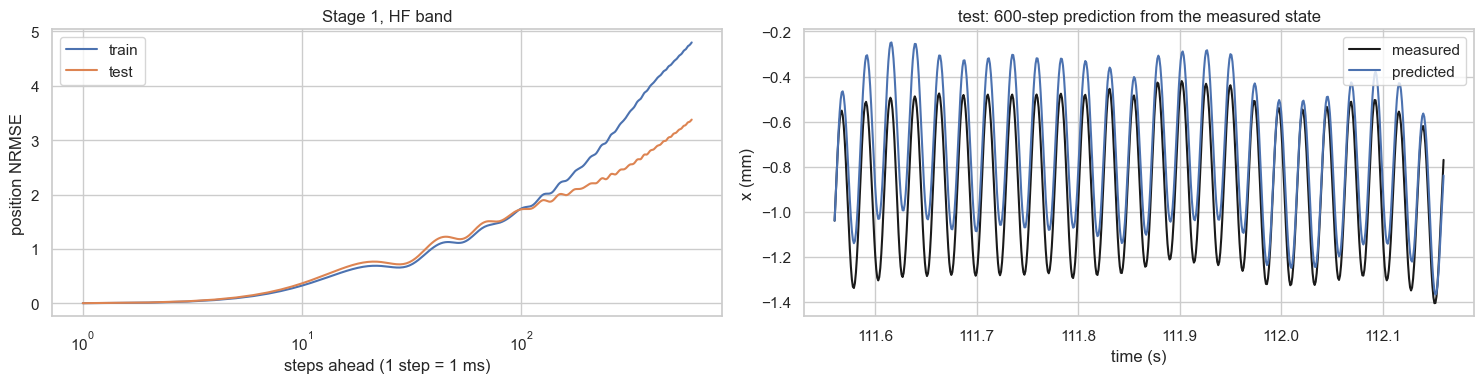

In [93]:
evaluate("Stage 1", stage1_force, p_hf, "chirp", "hf", H=600)

## Method A: cubic spring, LLS

Polynomial spring with an even term for asymmetry, fitted by bounded linear least squares on the scheduled chirp up to `F_MAX_A` Hz. Each row is divided by the local current amplitude, so the high-current end does not dominate.

$$m\ddot{x} = (\Gamma\,[+\,\Gamma_1 x])\, i - c\,\dot{x} - (k_1 x + k_2 x^2 + k_3 x^3)$$

Options (set in the first line of the cell):
- `FREE_GC = False`: $\Gamma$ and $c$ are fixed at the Stage 1 values.
- `FREE_GC = True`: $\Gamma$ and $c$ are refitted here, together with the spring ($c \geq 0$).
- `GAMMA_X = False`: constant motor constant $\Gamma$.
- `GAMMA_X = True`: position-dependent motor constant $\Gamma(x) = \Gamma + \Gamma_1 x$.

Always: $k_3 \geq 0$, so the spring hardens with stroke and keeps its restoring force outside the fitted range.

In [94]:
FREE_GC, GAMMA_X = True, True                           # refit Gamma and c here; position-dependent Gamma(x) = Gamma + Gamma1 x
poly3 = lambda x, u, q: q[-3] * x + q[-2] * x**2 + q[-1] * x**3 - (q[0] * x * u if GAMMA_X else 0.0)   # q = [Gamma1,] k1, k2, k3
d, sel = DATA["chirpsched"]["train"], DATA["chirpsched"]["train"]["sweep"]
x, i, v = d["x"][sel], d["i"][sel], d["v"][sel]
w = 1 / np.abs(signal.hilbert(d["i"]))[sel]                          # 1 / current amplitude, so every part of the sweep counts about equally
cols = {"k1": -x, "k2": -x**2, "k3": -x**3}                         # m a = Gamma i - c v [+ Gamma1 x i] - (k1 x + k2 x^2 + k3 x^3)
if GAMMA_X:
    cols = {"Gamma1": x * i, **cols}
if FREE_GC:
    cols = {"Gamma": i, "c": -v, **cols}
y = M * d["a"][sel] if FREE_GC else M * d["a"][sel] - p_hf[0] * i + p_hf[1] * v   # fixed Gamma, c (Stage 1) moved to the left
A = np.column_stack(list(cols.values()))
lb = [0.0 if n in ("c", "k3") else -np.inf for n in cols]           # c >= 0; k3 >= 0: hardening spring
sc = np.linalg.norm(A * w[:, None], axis=0)                          # column scaling
q = dict(zip(cols, lsq_linear(A * w[:, None] / sc, y * w, bounds=(lb, np.inf)).x / sc))
G, c = (q.pop("Gamma"), q.pop("c")) if FREE_GC else p_hf[:2]
p_p3 = np.r_[G, c, list(q.values())]
print(f"Gamma = {G:.1f} N/A, c = {c:.1f} N s/m ({'fitted here' if FREE_GC else 'Stage 1'}); " + ", ".join(f"{n} = {val:.4g}" for n, val in q.items()))
if GAMMA_X:
    print("Gamma(x)/Gamma at -5, +5 mm: " + ", ".join(f"{1 + q['Gamma1'] * xx / G:.3f}" for xx in (-5e-3, 5e-3)))

Gamma = 235.3 N/A, c = 2133.5 N s/m (fitted here); Gamma1 = 6536, k1 = 5.856e+04, k2 = -9.707e+05, k3 = 2.019e-20
Gamma(x)/Gamma at -5, +5 mm: 0.861, 1.139


train NRMSE at k = 1, 10, 100, 1000: 0.003, 0.195, 0.773, 0.713
test  NRMSE at k = 1, 10, 100, 1000: 0.003, 0.180, 0.642, 0.594


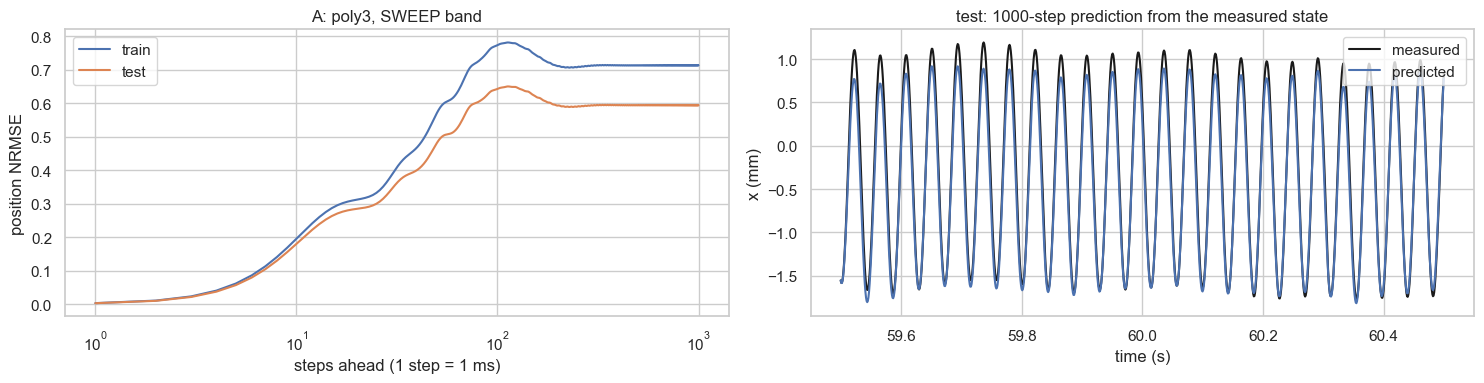

In [103]:
evaluate("A: poly3", poly3, p_p3, "chirpsched", "sweep", H=1000)

## Method B: cubic spring with the datasheet motor constant shape, LLS

Method A's model, but the motor constant follows the shape of the actuator datasheet curve, $K_f(z) = 283 - 0.0198\,z - 0.578\,z^2$ (N/A, $z$ in mm). Only its scale $\Gamma_0$ is fitted, so the motor term cannot take over the role of the spring. Same data and weighting as Method A.

$$m\ddot{x} = \Gamma_0\, s(x)\, i - c\,\dot{x} - (k_1 x + k_2 x^2 + k_3 x^3), \qquad s(x) = \frac{K_f(x)}{283} \;(= 1 \text{ at the centre})$$

Options (set in the first line of the cell):
- `FREE_GC = False`: $\Gamma_0$ and $c$ are fixed at the Stage 1 values.
- `FREE_GC = True`: $\Gamma_0$ and $c$ are refitted here, together with the spring ($c \geq 0$).

Always: the datasheet shape $s(x)$, and $k_3 \geq 0$, so the spring hardens with stroke.

In [99]:
FREE_GC = True                                          # refit Gamma0 and c here; False: Stage 1 values
d, sel = DATA["chirpsched"]["train"], DATA["chirpsched"]["train"]["sweep"]
x, i, v = d["x"][sel], d["i"][sel], d["v"][sel]
w = 1 / np.abs(signal.hilbert(d["i"]))[sel]                          # 1 / current amplitude, so every part of the sweep counts about equally
cols = {"k1": -x, "k2": -x**2, "k3": -x**3}                         # m a = Gamma0 s(x) i - c v - (k1 x + k2 x^2 + k3 x^3)
if FREE_GC:
    cols = {"Gamma0": i * s_ds(x), "c": -v, **cols}
y = M * d["a"][sel] if FREE_GC else M * d["a"][sel] - p_hf[0] * s_ds(x) * i + p_hf[1] * v   # fixed Gamma0, c (Stage 1) moved to the left
A = np.column_stack(list(cols.values()))
lb = [0.0 if n in ("c", "k3") else -np.inf for n in cols]           # c >= 0; k3 >= 0: hardening spring
sc = np.linalg.norm(A * w[:, None], axis=0)                          # column scaling
q = dict(zip(cols, lsq_linear(A * w[:, None] / sc, y * w, bounds=(lb, np.inf)).x / sc))
G0, c = (q.pop("Gamma0"), q.pop("c")) if FREE_GC else p_hf[:2]
p_B = np.r_[G0, c, list(q.values())]
poly3_ds = lambda x, u, q, G0=G0: q[0] * x + q[1] * x**2 + q[2] * x**3 + G0 * (1 - s_ds(x)) * u   # spring, plus Gamma0 (1 - s(x)) i so the motor force is Gamma0 s(x) i
print(f"Gamma0 = {G0:.1f} N/A, c = {c:.1f} N s/m ({'fitted here' if FREE_GC else 'Stage 1'}); " + ", ".join(f"{n} = {val:.4g}" for n, val in q.items()))
print("Gamma(x)/Gamma0 at -5, +5 mm (datasheet shape): " + ", ".join(f"{s_ds(xx):.3f}" for xx in (-5e-3, 5e-3)))

Gamma0 = 231.0 N/A, c = 2104.9 N s/m (fitted here); k1 = 6.426e+04, k2 = 5.401e+06, k3 = 2.635e-13
Gamma(x)/Gamma0 at -5, +5 mm (datasheet shape): 0.949, 0.949


train NRMSE at k = 1, 10, 100, 1000: 0.003, 0.199, 0.892, 0.900
test  NRMSE at k = 1, 10, 100, 1000: 0.003, 0.183, 0.803, 0.783


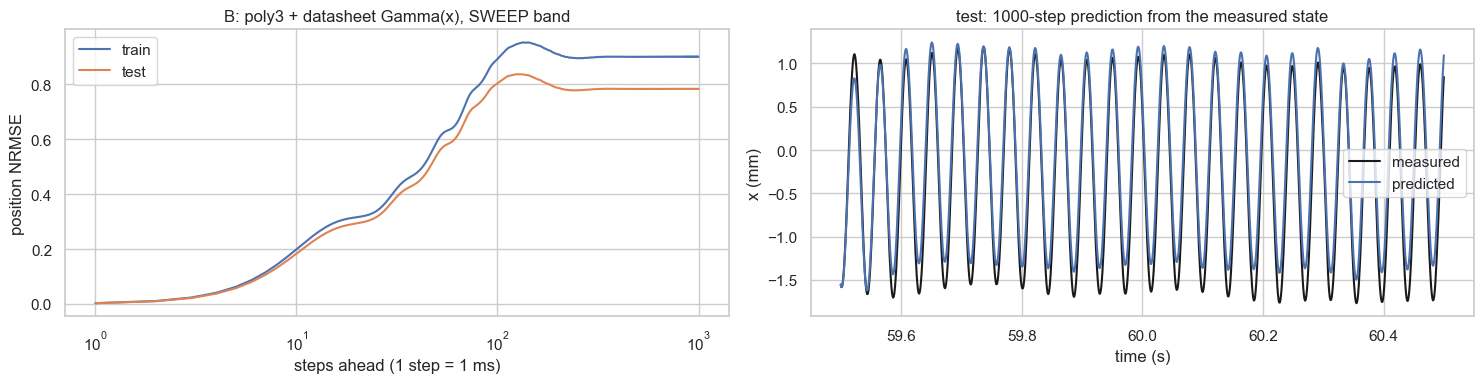

In [100]:
evaluate("B: poly3 + datasheet Gamma(x)", poly3_ds, p_B, "chirpsched", "sweep", H=1000)

## Method C: unequal magnets with the datasheet motor constant shape, LLS

Two repelling magnets with their own strength, $C_R, C_L \geq 0$ (PDF eq. 3 with $Q_R \neq Q_L$): each always repels, and the net spring always restores and stiffens with stroke. $C_R \neq C_L$ gives the asymmetry. The gap is fixed at the measured $g_0$ = `G00` = 22.3 mm, so the model is linear in $C_R, C_L$. The motor constant follows the datasheet shape $s(x)$ as in Method B, and only its scale $\Gamma_0$ is fitted. Same data and weighting as Method A.

$$m\ddot{x} = \Gamma_0\, s(x)\, i - c\,\dot{x} - \left(\frac{C_R}{(g_0 - x)^2} - \frac{C_L}{(g_0 + x)^2}\right)$$

Options (set in the first line of the cell):
- `FREE_GC = False`: $\Gamma_0$ and $c$ are fixed at the Stage 1 values.
- `FREE_GC = True`: $\Gamma_0$ and $c$ are refitted here, together with $C_R, C_L$ ($c \geq 0$).

Always: the datasheet shape $s(x)$, $g_0$ = 22.3 mm, and $C_R, C_L \geq 0$.

In [101]:
FREE_GC = True                                          # refit Gamma0 and c here; False: Stage 1 values
d, sel = DATA["chirpsched"]["train"], DATA["chirpsched"]["train"]["sweep"]
x, i, v = d["x"][sel], d["i"][sel], d["v"][sel]
w = 1 / np.abs(signal.hilbert(d["i"]))[sel]                          # 1 / current amplitude, so every part of the sweep counts about equally
cols = {"C_R": -1 / (G00 - x)**2, "C_L": 1 / (G00 + x)**2}          # m a = Gamma0 s(x) i - c v - (C_R / (g0 - x)^2 - C_L / (g0 + x)^2)
if FREE_GC:
    cols = {"Gamma0": i * s_ds(x), "c": -v, **cols}
y = M * d["a"][sel] if FREE_GC else M * d["a"][sel] - p_hf[0] * s_ds(x) * i + p_hf[1] * v   # fixed Gamma0, c (Stage 1) moved to the left
A = np.column_stack(list(cols.values()))
lb = [-np.inf if n == "Gamma0" else 0.0 for n in cols]              # c, C_R, C_L >= 0
sc = np.linalg.norm(A * w[:, None], axis=0)                          # column scaling
q = dict(zip(cols, lsq_linear(A * w[:, None] / sc, y * w, bounds=(lb, np.inf)).x / sc))
G0, c = (q.pop("Gamma0"), q.pop("c")) if FREE_GC else p_hf[:2]
C_R, C_L = q["C_R"], q["C_L"]
p_C = np.r_[G0, c, C_R, C_L]
magnets_ds = lambda x, u, q, G0=G0: q[0] / (G00 - x)**2 - q[1] / (G00 + x)**2 + G0 * (1 - s_ds(x)) * u   # magnets, plus Gamma0 (1 - s(x)) i
print(f"Gamma0 = {G0:.1f} N/A, c = {c:.1f} N s/m ({'fitted here' if FREE_GC else 'Stage 1'}); C_R = {C_R:.4g} N m^2, C_L = {C_L:.4g} N m^2 "
      f"(C_R / C_L = {C_R / C_L:.3f}; PDF guess C_mu = {CMU0} N m^2)")
print(f"stiffness at x = 0: {2 * (C_R + C_L) / G00**3:.3g} N/m, force at x = 0: {(C_R - C_L) / G00**2:.3g} N")

Gamma0 = 229.9 N/A, c = 2094.1 N s/m (fitted here); C_R = 0.1814 N m^2, C_L = 0.1756 N m^2 (C_R / C_L = 1.033; PDF guess C_mu = 2.423 N m^2)
stiffness at x = 0: 6.44e+04 N/m, force at x = 0: 11.7 N


train NRMSE at k = 1, 10, 100, 1000: 0.003, 0.199, 0.910, 0.836
test  NRMSE at k = 1, 10, 100, 1000: 0.003, 0.182, 0.773, 0.709


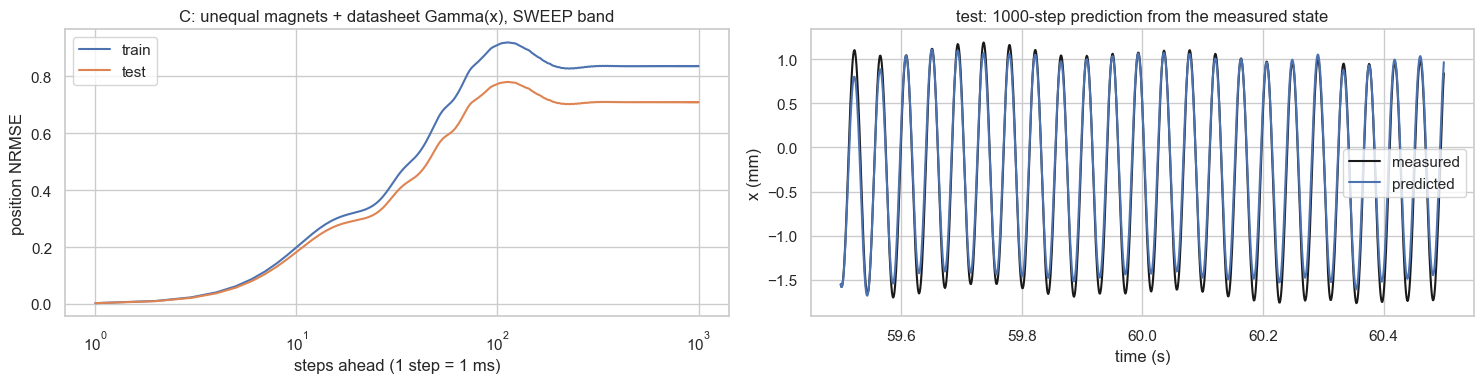

In [102]:
evaluate("C: unequal magnets + datasheet Gamma(x)", magnets_ds, p_C, "chirpsched", "sweep", H=1000)